<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Programacion1Sem/Practica_25_Arbol_de_Decisi%C3%B3n_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica # 25: Arbol de Decisión 1
Alumno: Marco Antonio Muñoz Quiroz

**Link Github**

# 1. Carga de Datos: Carga el conjunto de datos de vivienda desde una URL pública.

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv"

columnas = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
            'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv(url, header=None, names=columnas)
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


**Descripcion de las vavriables:**

**CRIM:** Tasa de criminalidad per capita por ciudad. Representa el nivel de seguridad del area.

**ZN:** Porcentaje de terrenos residenciales con lotes grandes. Indica el nivel de urbanizacion o exclusividad de la zona.

**INDUS:** Proporcion de acres dedicados a negocios industriales. Un valor alto indica una zona menos residencial.

**CHAS:** Variable dummy (0 o 1) que indica si el area limita con el rio Charles. Un valor de 1 significa que la propiedad esta junto al rio.

**NOX:** Concentracion de oxidos de nitrogeno en el aire (indicador de contaminacion ambiental).

**RM:** Numero promedio de habitaciones por vivienda. Suele relacionarse con el tamaño y valor de la propiedad.

**AGE:** Proporcion de viviendas construidas antes de 1940. Representa la antiguedad de la zona.

**DIS:** Distancias promedio a cinco centros principales de empleo. Indica cercania a oportunidades laborales.

**RAD:** Indice de accesibilidad a autopistas radiales. Valores altos implican mejor acceso a carreteras importantes.

**TAX:** Tasa de impuesto a la propiedad por cada 10,000 dolares. Un factor economico relevante para el costo de vida.

**PTRATIO:** Relacion estudiantes por profesor en las escuelas de la zona. Valores bajos indican mejor atencion educativa.

**B:** Proporcion de habitantes afroamericanos calculada como 1000 × (Bk − 0.63)^2. Esta variable proviene del estudio original.

**LSTAT:** Porcentaje de poblacion con bajo nivel socioeconomico. Es un indicador de status social en la zona.

**MEDV:** Valor medio de la vivienda en miles de dolares. Es la variable que se desea predecir o analizar.

# 2. Análisis de Datos: Realiza un análisis descriptivo y visualiza la distribución de las características.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [3]:
def header(titulo: str):
    # creamos un marco con caracteres de caja para resaltar el titulo
    texto = f" {titulo.strip()} "
    linea = "═" * len(texto)
    print(f"\n╔{linea}╗")
    print(f"║{texto}║")
    print(f"╚{linea}╝")

In [4]:
# configuramos pandas para mostrar todas las columnas sin cortar lineas
# esto evita que las tablas largas se partan en varias lineas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", None)

In [5]:
# inspeccionamos forma, tipos y nulos para entender la estructura basica de los datos
header("Forma del DataFrame (filas, columnas)")
print(df.shape)

header("Tipos de datos por columna")
print(df.dtypes.to_string())

header("Conteo de valores nulos por columna")
print(df.isna().sum().to_string())

header("Primeras 5 filas para una vista rapida")
print(df.head().to_string(index=False))

# calculamos medidas basicas (min, Q1, mediana, media, Q3, max, std) para cada variable
desc = df.describe().T  # transponemos para leer por filas (una fila por variable)

# agregamos sesgo (skewness) y curtosis para entender forma de la distribucion
# skew > 0 sugiere cola a la derecha; skew < 0 sugiere cola a la izquierda
# kurtosis > 3 sugiere colas mas pesadas que una normal
desc["skew"] = df.apply(pd.Series.skew, numeric_only=True)
desc["kurtosis"] = df.apply(pd.Series.kurtosis, numeric_only=True)

header("Estadistica descriptiva con skew y kurtosis")
print(desc.round(4).to_string())


╔═══════════════════════════════════════╗
║ Forma del DataFrame (filas, columnas) ║
╚═══════════════════════════════════════╝
(506, 14)

╔════════════════════════════╗
║ Tipos de datos por columna ║
╚════════════════════════════╝
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64

╔═════════════════════════════════════╗
║ Conteo de valores nulos por columna ║
╚═════════════════════════════════════╝
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0

╔════════════════════════════════════════╗
║ Primeras 5 filas para una vista rapida ║
╚════════════════════════════════════════╝
   CRIM   ZN  INDUS  CHAS   NOX    RM  AGE    DIS  RAD   TAX  PTRATIO 

In [6]:
# exploramos CHAS (0/1) y RAD (enteros) para ver su distribucion de frecuencias
if "CHAS" in df.columns:
    header("Frecuencias en CHAS (0 = no colinda con el rio, 1 = si colinda)")
    print(df["CHAS"].value_counts().sort_index().to_string())

if "RAD" in df.columns:
    header("Frecuencias en RAD (indice de acceso a autopistas)")
    print(df["RAD"].value_counts().sort_index().to_string())


╔═════════════════════════════════════════════════════════════════╗
║ Frecuencias en CHAS (0 = no colinda con el rio, 1 = si colinda) ║
╚═════════════════════════════════════════════════════════════════╝
CHAS
0    471
1     35

╔════════════════════════════════════════════════════╗
║ Frecuencias en RAD (indice de acceso a autopistas) ║
╚════════════════════════════════════════════════════╝
RAD
1      20
2      24
3      38
4     110
5     115
6      26
7      17
8      24
24    132



╔═════════════════════════╗
║ Histogramas por columna ║
╚═════════════════════════╝


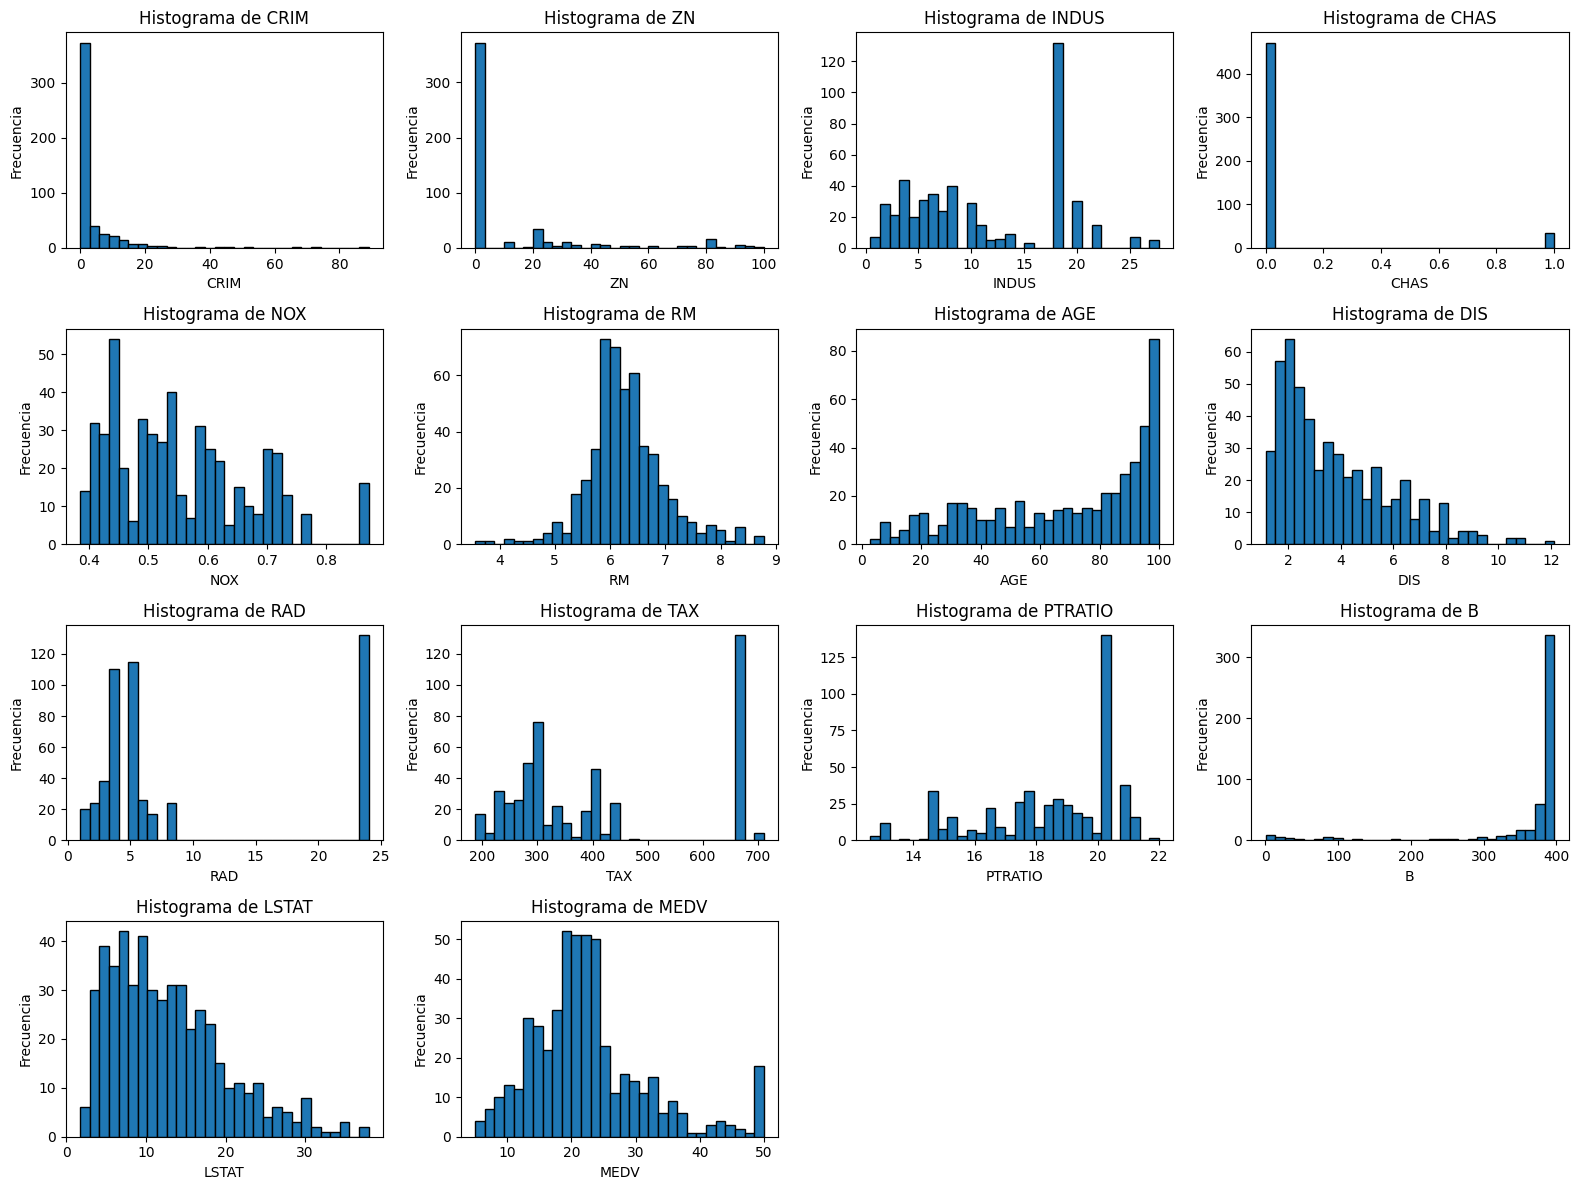

In [7]:
# graficamos histogramas para observar simetria, sesgo y dispersion de cada variable
num_cols = df.columns.tolist()

# organizamos las graficas en una cuadricula; 14 columnas ~ 4 filas x 4 columnas funciona
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

header("Histogramas por columna")
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    # elegimos 30 bins como punto de partida para lograr buen detalle sin exceso de ruido
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


╔══════════════════════╗
║ Boxplots por columna ║
╚══════════════════════╝


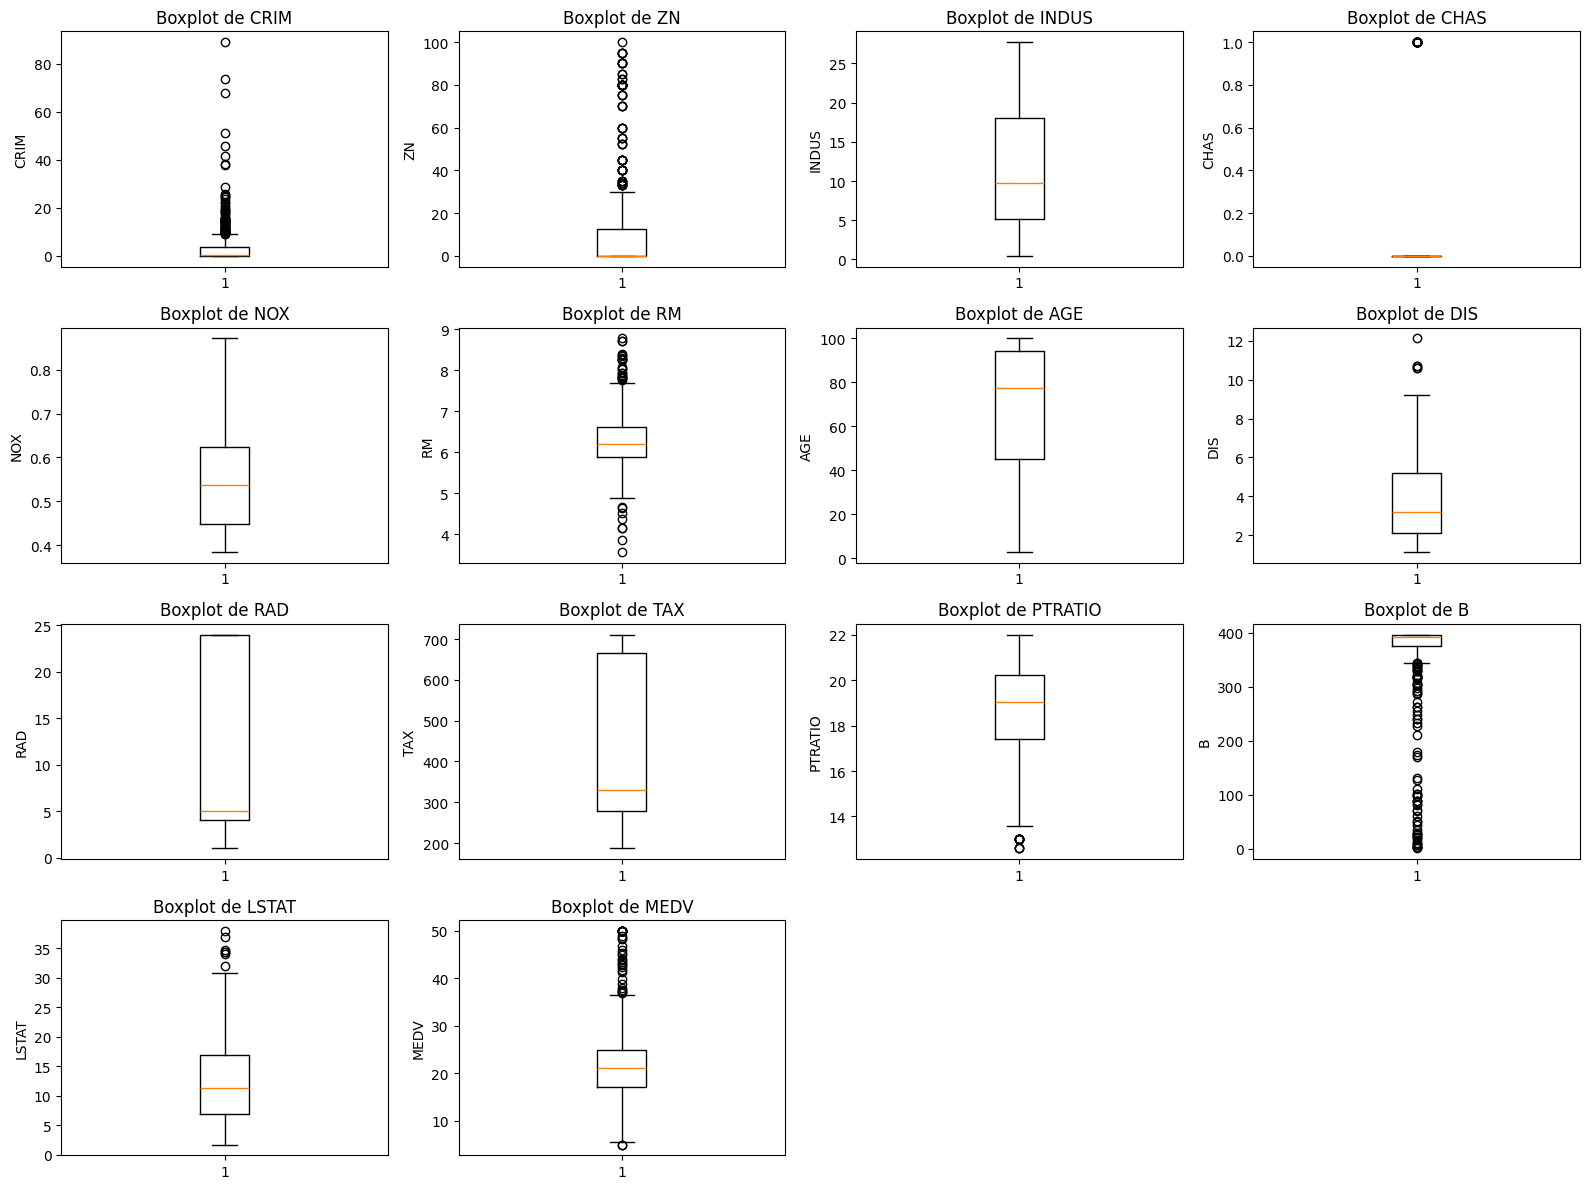

In [8]:
header("Boxplots por columna")
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col].dropna(), vert=True, showfliers=True)
    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [9]:
# marcamos como outliers los valores fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] para cada variable
outlier_resumen = []
for col in num_cols:
    serie = df[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    outlier_resumen.append({"columna": col, "outliers_IQR": int(n_out)})

outlier_df = pd.DataFrame(outlier_resumen).sort_values("outliers_IQR", ascending=False)
header("Conteo de outliers por IQR (mayor a menor)")
print(outlier_df.to_string(index=False))


╔════════════════════════════════════════════╗
║ Conteo de outliers por IQR (mayor a menor) ║
╚════════════════════════════════════════════╝
columna  outliers_IQR
      B            77
     ZN            68
   CRIM            66
   MEDV            40
   CHAS            35
     RM            30
PTRATIO            15
  LSTAT             7
    DIS             5
  INDUS             0
    NOX             0
    TAX             0
    AGE             0
    RAD             0



╔════════════════════════════════════════════╗
║ Matriz de correlacion (impresion completa) ║
╚════════════════════════════════════════════╝
          CRIM     ZN  INDUS   CHAS    NOX     RM    AGE    DIS    RAD    TAX  PTRATIO      B  LSTAT   MEDV
CRIM     1.000 -0.200  0.407 -0.056  0.421 -0.219  0.353 -0.380  0.626  0.583    0.290 -0.385  0.456 -0.388
ZN      -0.200  1.000 -0.534 -0.043 -0.517  0.312 -0.570  0.664 -0.312 -0.315   -0.392  0.176 -0.413  0.360
INDUS    0.407 -0.534  1.000  0.063  0.764 -0.392  0.645 -0.708  0.595  0.721    0.383 -0.357  0.604 -0.484
CHAS    -0.056 -0.043  0.063  1.000  0.091  0.091  0.087 -0.099 -0.007 -0.036   -0.122  0.049 -0.054  0.175
NOX      0.421 -0.517  0.764  0.091  1.000 -0.302  0.731 -0.769  0.611  0.668    0.189 -0.380  0.591 -0.427
RM      -0.219  0.312 -0.392  0.091 -0.302  1.000 -0.240  0.205 -0.210 -0.292   -0.356  0.128 -0.614  0.695
AGE      0.353 -0.570  0.645  0.087  0.731 -0.240  1.000 -0.748  0.456  0.506    0.262 -0.274  0.602 -

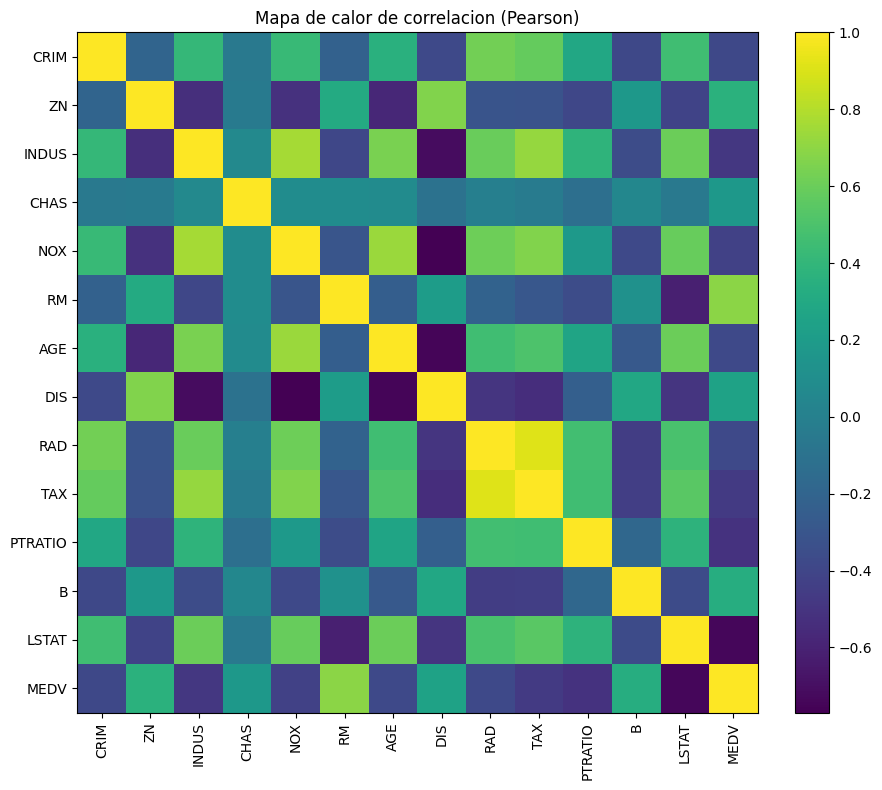

In [10]:
# calculamos correlacion de Pearson para entender relaciones lineales entre variables
corr = df.corr(numeric_only=True)

header("Matriz de correlacion (impresion completa)")
print(corr.round(3).to_string())

header("Mapa de calor de correlacion (Pearson)")
plt.figure(figsize=(10, 8))
im = plt.imshow(corr, interpolation="nearest")
plt.title("Mapa de calor de correlacion (Pearson)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.index)), labels=corr.index)
plt.tight_layout()
plt.show()

# 3. Preprocesamiento: Maneje cualquier valor nulo y codifica las características si es necesario.

In [11]:
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

header("Revision rapida de nulos (solo verificacion)")
print("Nulos en X por columna:\n", X.isna().sum().to_string())
print("\nNulos en y:", int(y.isna().sum()))

# Convertimos SOLO CHAS y RAD a categoricas
# convertimos CHAS (0/1) a etiquetas legibles y a tipo category
if "CHAS" in X.columns:
    X["CHAS"] = X["CHAS"].map({0: "no_river", 1: "river"}).astype("category")

# convertimos RAD (indice discreto) a strings y luego a category
if "RAD" in X.columns:
    X["RAD"] = X["RAD"].astype(int).astype(str).astype("category")

# armamos listas finales: cat_cols solo con CHAS y RAD si existen; num_cols el resto
cat_cols = [c for c in ["CHAS", "RAD"] if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

header("Columnas por tipo (solo CHAS y RAD como categoricas)")
print("Categoricas:", cat_cols if cat_cols else "ninguna")
print("Numericas:", num_cols if num_cols else "ninguna")

# para categoricas aplicamos one-hot encoding, para numericas hacemos passthrough (no tocamos nada)
preprocess = ColumnTransformer(transformers=[
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], remainder="drop")

# Ajustamos y transformamos X para obtener X_processed
X_processed_np = preprocess.fit_transform(X)

# reconstruimos nombres de caracteristicas para interpretar el resultado
feature_names = []
# primero las numericas (se conservan igual)
feature_names.extend(num_cols)
# luego las categorias expandidas por one-hot (si existen)
if cat_cols:
    ohe = preprocess.named_transformers_["cat"]
    ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names.extend(ohe_names)

# construimos el DataFrame procesado
X_processed = pd.DataFrame(X_processed_np, columns=feature_names, index=X.index)

# Resumen final
header("Resumen final de la transformacion (sin imputaciones)")
print("Forma original de X:", X.shape)
print("Forma procesada de X:", X_processed.shape)

header("Verificacion de nulos en X_processed")
print(X_processed.isna().sum().to_string())

header("columnas de X_processed")
print(feature_names[:25])

header("filas de X_processed")
print(X_processed.head(5).to_string(index=False))

print("\nX_processed e y estan listas para el split train/test y el modelo")


╔══════════════════════════════════════════════╗
║ Revision rapida de nulos (solo verificacion) ║
╚══════════════════════════════════════════════╝
Nulos en X por columna:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0

Nulos en y: 0

╔══════════════════════════════════════════════════════╗
║ Columnas por tipo (solo CHAS y RAD como categoricas) ║
╚══════════════════════════════════════════════════════╝
Categoricas: ['CHAS', 'RAD']
Numericas: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']

╔═══════════════════════════════════════════════════════╗
║ Resumen final de la transformacion (sin imputaciones) ║
╚═══════════════════════════════════════════════════════╝
Forma original de X: (506, 13)
Forma procesada de X: (506, 22)

╔══════════════════════════════════════╗
║ Verificacion de nulos en X_processed ║
╚══════════════════════════

# 4. División de Conjuntos: Divida los datos en conjuntos de entrenamiento y prueba.

In [12]:
# no usamos stratify porque es un problema de REGRESION:
# stratify se usa para mantener la proporcion de CLASES en clasificacion,
# pero aqui y (MEDV) es continua y no existen clases que estratificar

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.25, random_state=13
)

# verificamos dimensiones para confirmar que la division quedo correcta
print("X_train:", X_train.shape, " | X_test:", X_test.shape)
print("y_train:", y_train.shape, " | y_test:", y_test.shape)

X_train: (379, 22)  | X_test: (127, 22)
y_train: (379,)  | y_test: (127,)


# 5. Entrenamiento: Entrene un árbol de decisión.


╔═══════════════════════════════════════════════════╗
║ Desempeno del modelo base (DecisionTreeRegressor) ║
╚═══════════════════════════════════════════════════╝
MAE  train: 0.000 | MAE  test: 3.099
RMSE train: 0.000 | RMSE test: 5.260
R2   train: 1.000 | R2   test: 0.691

╔══════════════════════╗
║ Estructura del arbol ║
╚══════════════════════╝
Profundidad del arbol: 20
Numero de hojas     : 356

╔════════════════════════════════════════╗
║ Top 10 importancias de caracteristicas ║
╚════════════════════════════════════════╝
RM         0.5743
LSTAT      0.1907
DIS        0.1368
TAX        0.0252
CRIM       0.0223
B          0.0123
PTRATIO    0.0106
AGE        0.0093
NOX        0.0059
INDUS      0.0050


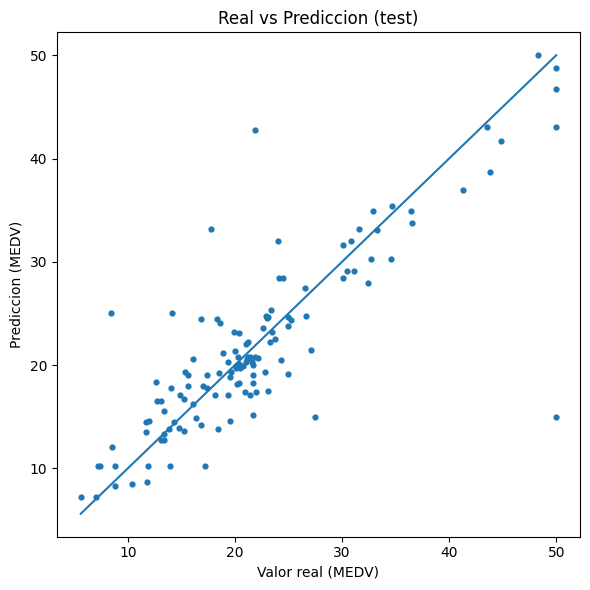

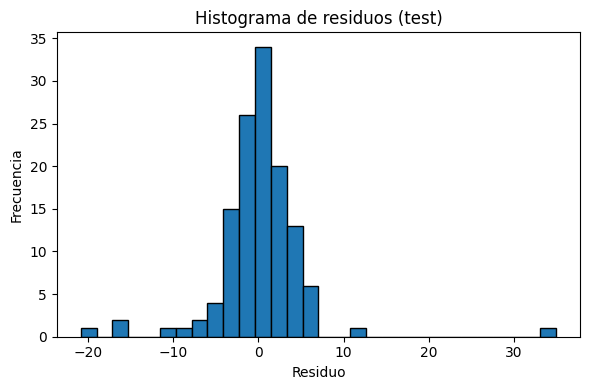

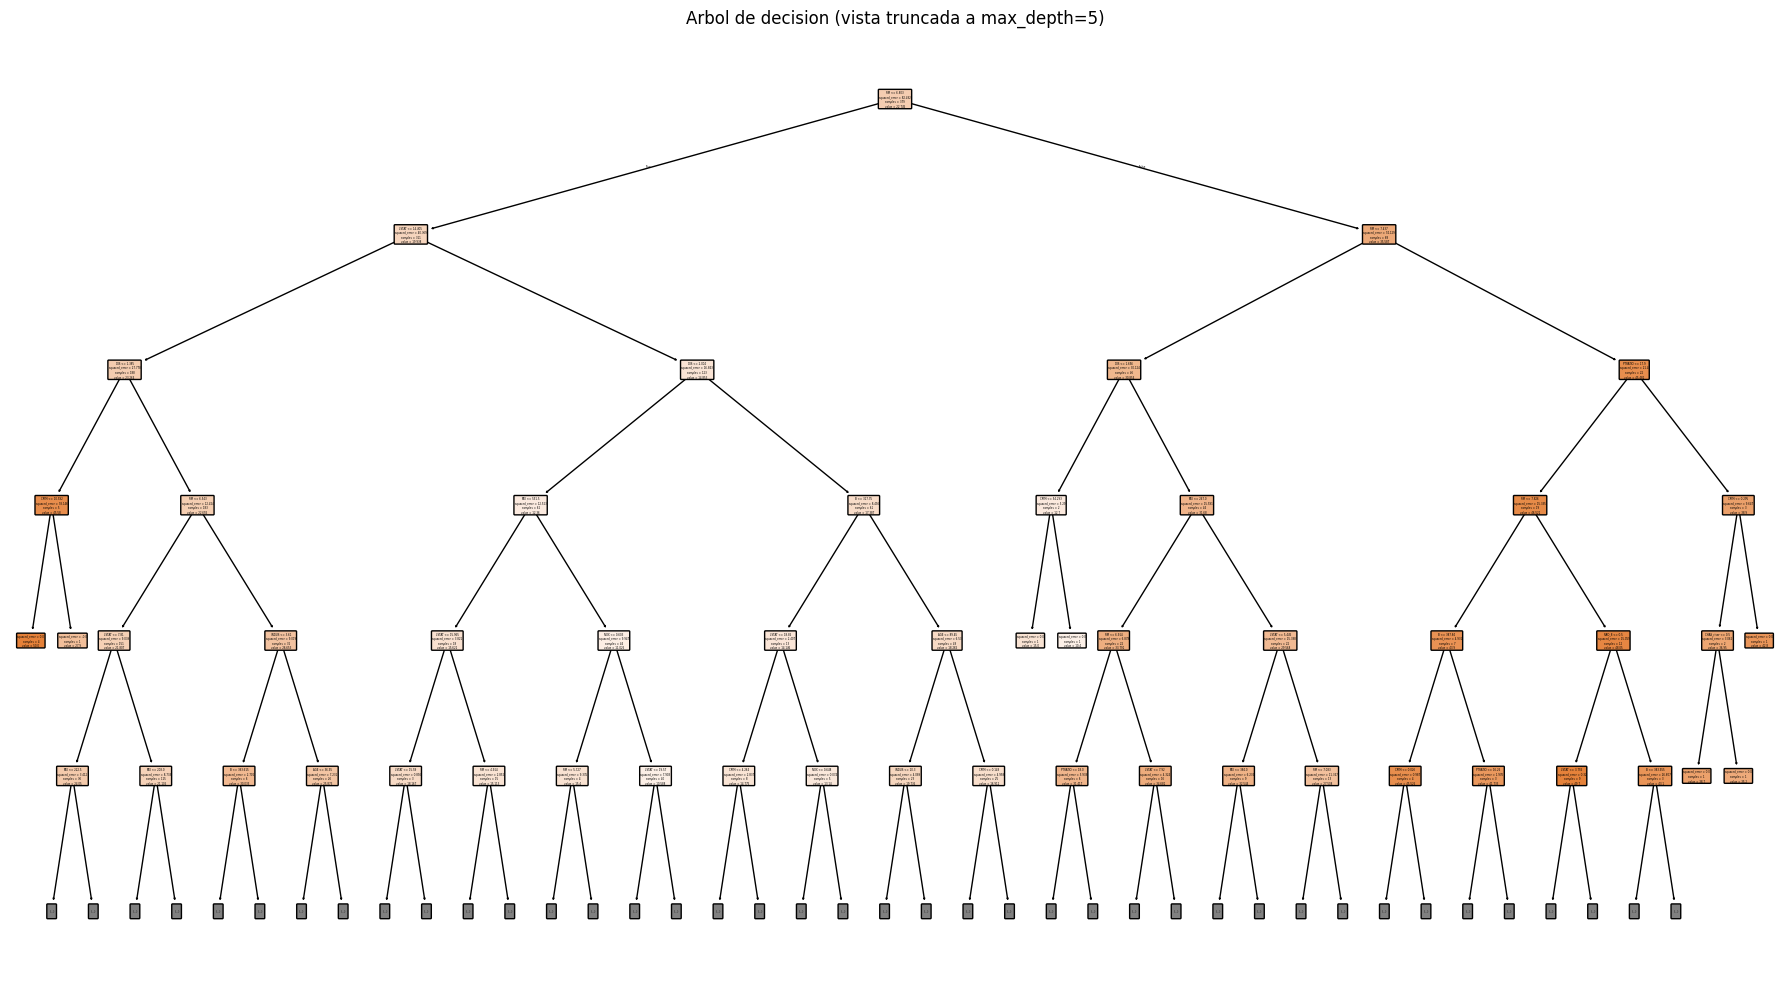

In [13]:
# Entrenamiento de un arbol de decision para REGRESION (MEDV continuo) sin profundidad especificada

# entrenamos un modelo base con hiperparametros sencillos
# idea: arrancamos con limites suaves para evitar sobreajuste extremo
reg_base = DecisionTreeRegressor(
    random_state=42,       # fijamos semilla para poder repetir resultados
    max_depth=None,        # sin limite de profundidad por ahora
    min_samples_split=2,   # division minima por nodo
    min_samples_leaf=1     # muestras minimas por hoja
)

# ajustamos el modelo con los datos de entrenamiento
reg_base.fit(X_train, y_train)

# hacemos predicciones en train y test
y_pred_train = reg_base.predict(X_train)
y_pred_test  = reg_base.predict(X_test)

# calculamos metricas de error y ajuste
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

# imprimimos un resumen compacto de desempeno
header("Desempeno del modelo base (DecisionTreeRegressor)")
print(f"MAE  train: {mae_train:.3f} | MAE  test: {mae_test:.3f}")
print(f"RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")
print(f"R2   train: {r2_train:.3f} | R2   test: {r2_test:.3f}")

# mostramos detalles de la estructura del arbol
header("\nEstructura del arbol")
print(f"Profundidad del arbol: {reg_base.get_depth()}")
print(f"Numero de hojas     : {reg_base.get_n_leaves()}")

# importancias de caracteristicas para interpretar que variables usa mas el arbol
importances = pd.Series(reg_base.feature_importances_, index=X_train.columns).sort_values(ascending=False)
header("\nTop 10 importancias de caracteristicas")
print(importances.head(10).round(4).to_string())

# grafico 1: valores reales vs predichos en test
# usamos este scatter para ver que tan alineado esta el modelo a la diagonal ideal
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, s=12)
min_v = min(y_test.min(), y_pred_test.min())
max_v = max(y_test.max(), y_pred_test.max())
plt.plot([min_v, max_v], [min_v, max_v])  # linea diagonal ideal
plt.xlabel("Valor real (MEDV)")
plt.ylabel("Prediccion (MEDV)")
plt.title("Real vs Prediccion (test)")
plt.tight_layout()
plt.show()

# grafico 2: distribucion de residuos en test (y_real - y_pred)
# buscamos residuos centrados en 0 y sin colas extremas
res_test = y_test - y_pred_test
plt.figure(figsize=(6, 4))
plt.hist(res_test, bins=30, edgecolor="black")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Histograma de residuos (test)")
plt.tight_layout()
plt.show()

# grafico 3 (opcional): visualizacion parcial del arbol
# advertencia: si el arbol es muy profundo, esta grafica puede ser grande
plt.figure(figsize=(18, 10))
plot_tree(
    reg_base,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=5  # recortamos la profundidad para que la figura sea legible
)
plt.title("Arbol de decision (vista truncada a max_depth=5)")
plt.tight_layout()
plt.show()

# notas didacticas:
# - si vemos R2 train muy alto y R2 test mucho mas bajo, sospechamos sobreajuste
# - para controlar complejidad podemos ajustar max_depth, min_samples_leaf, min_samples_split
# - las importancias nos orientan sobre que variables usa mas el arbol para dividir


# 6. Optimización: Experimente con la profundidad del árbol (max_depth) y observa cómo afecta la precisión.


╔═══════════════════════════════════════════════════╗
║ Desempeno del modelo base (DecisionTreeRegressor) ║
╚═══════════════════════════════════════════════════╝
MAE  train: 1.526 | MAE  test: 2.517
RMSE train: 2.069 | RMSE test: 3.502
R2   train: 0.948 | R2   test: 0.863

╔══════════════════════╗
║ Estructura del arbol ║
╚══════════════════════╝
Profundidad del arbol: 6
Numero de hojas     : 47

╔════════════════════════════════════════╗
║ Top 10 importancias de caracteristicas ║
╚════════════════════════════════════════╝
RM         0.5981
LSTAT      0.1985
DIS        0.1125
NOX        0.0261
TAX        0.0238
CRIM       0.0149
B          0.0074
PTRATIO    0.0062
AGE        0.0048
INDUS      0.0036


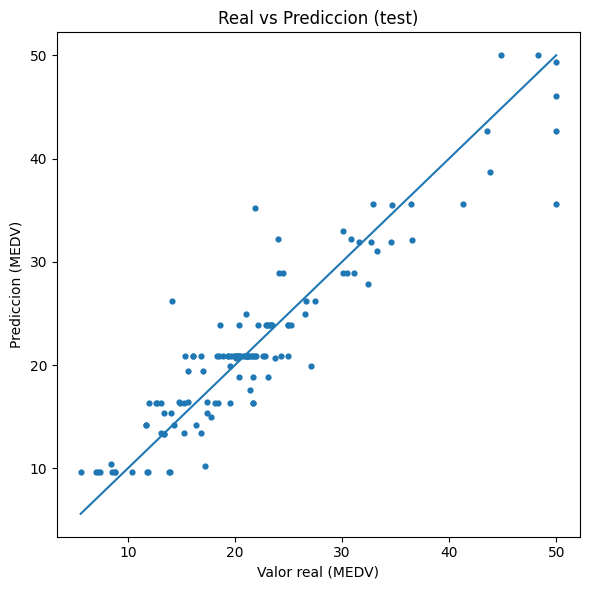

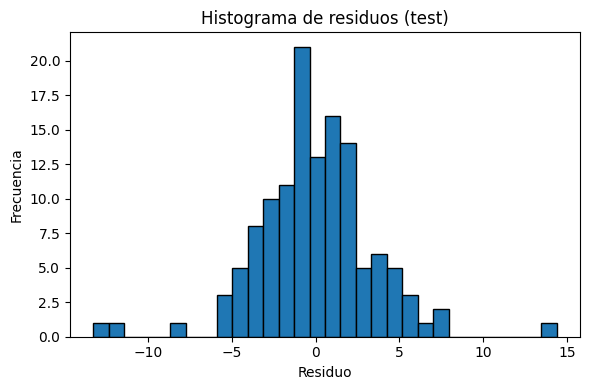

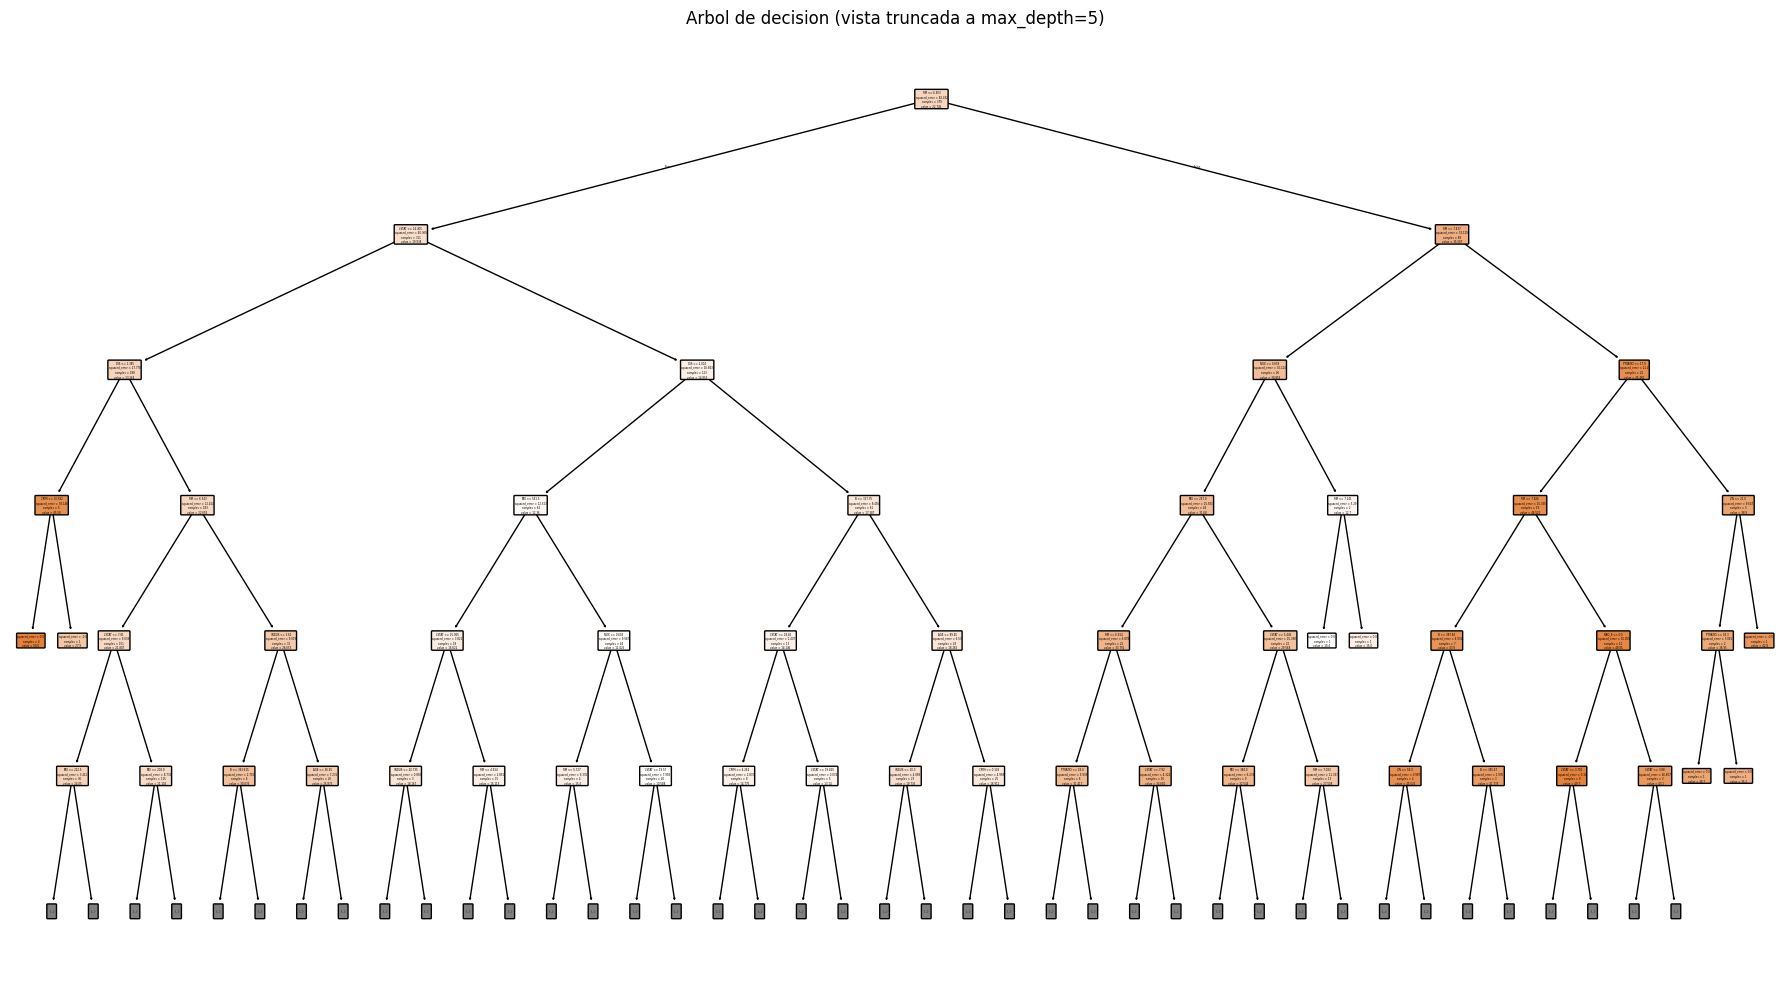

In [14]:
# Entrenamiento de un arbol de decision para REGRESION (MEDV continuo) Con profundidad de 5 niveles

# entrenamos un modelo base con hiperparametros sencillos
# idea: arrancamos con limites suaves para evitar sobreajuste extremo
reg_base = DecisionTreeRegressor(
    random_state=42,       # fijamos semilla para poder repetir resultados
    max_depth=6,        # Este valor es el que menor error arrojo
    min_samples_split=2,   # division minima por nodo
    min_samples_leaf=1     # muestras minimas por hoja
)

# ajustamos el modelo con los datos de entrenamiento
reg_base.fit(X_train, y_train)

# hacemos predicciones en train y test
y_pred_train = reg_base.predict(X_train)
y_pred_test  = reg_base.predict(X_test)

# calculamos metricas de error y ajuste
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test,  y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

# imprimimos un resumen compacto de desempeno
header("Desempeno del modelo base (DecisionTreeRegressor)")
print(f"MAE  train: {mae_train:.3f} | MAE  test: {mae_test:.3f}")
print(f"RMSE train: {rmse_train:.3f} | RMSE test: {rmse_test:.3f}")
print(f"R2   train: {r2_train:.3f} | R2   test: {r2_test:.3f}")

# mostramos detalles de la estructura del arbol
header("\nEstructura del arbol")
print(f"Profundidad del arbol: {reg_base.get_depth()}")
print(f"Numero de hojas     : {reg_base.get_n_leaves()}")

# importancias de caracteristicas para interpretar que variables usa mas el arbol
importances = pd.Series(reg_base.feature_importances_, index=X_train.columns).sort_values(ascending=False)
header("\nTop 10 importancias de caracteristicas")
print(importances.head(10).round(4).to_string())

# grafico 1: valores reales vs predichos en test
# usamos este scatter para ver que tan alineado esta el modelo a la diagonal ideal
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, s=12)
min_v = min(y_test.min(), y_pred_test.min())
max_v = max(y_test.max(), y_pred_test.max())
plt.plot([min_v, max_v], [min_v, max_v])  # linea diagonal ideal
plt.xlabel("Valor real (MEDV)")
plt.ylabel("Prediccion (MEDV)")
plt.title("Real vs Prediccion (test)")
plt.tight_layout()
plt.show()

# grafico 2: distribucion de residuos en test (y_real - y_pred)
# buscamos residuos centrados en 0 y sin colas extremas
res_test = y_test - y_pred_test
plt.figure(figsize=(6, 4))
plt.hist(res_test, bins=30, edgecolor="black")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Histograma de residuos (test)")
plt.tight_layout()
plt.show()

# grafico 3 (opcional): visualizacion parcial del arbol
# advertencia: si el arbol es muy profundo, esta grafica puede ser grande
plt.figure(figsize=(18, 10))
plot_tree(
    reg_base,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=5  # recortamos la profundidad para que la figura sea legible
)
plt.title("Arbol de decision (vista truncada a max_depth=5)")
plt.tight_layout()
plt.show()

# notas:
# - si vemos R2 train muy alto y R2 test mucho mas bajo, sospechamos sobreajuste
# - para controlar complejidad podemos ajustar max_depth, min_samples_leaf, min_samples_split
# - las importancias nos orientan sobre que variables usa mas el arbol para dividir


# 7. Evaluación: Evalúa el modelo utilizando precisión, recall y F1-score

In [15]:
resultados = []

# definimos el umbral para la evaluacion binaria usando SOLO y_train (evitamos fuga de informacion)
umbral = float(np.median(y_train))

# probamos profundidades desde 2 hasta 20, ademas de None (sin limite)
profundidades = list(range(2, 21)) + [None]

for d in profundidades:
    # entrenamos el arbol con la profundidad d
    reg = DecisionTreeRegressor(random_state=42, max_depth=d)
    reg.fit(X_train, y_train)

    # predecimos en train y test
    y_tr = reg.predict(X_train)
    y_te = reg.predict(X_test)

    # calculamos metricas de REGRESION
    mae_tr  = mean_absolute_error(y_train, y_tr)
    mae_te  = mean_absolute_error(y_test,  y_te)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr))  # usamos sqrt del MSE por compatibilidad
    rmse_te = np.sqrt(mean_squared_error(y_test,  y_te))  # idem
    r2_tr   = r2_score(y_train, y_tr)
    r2_te   = r2_score(y_test,  y_te)

    # convertimos a binario para calcular precision/recall/F1 como evaluacion complementaria
    y_test_bin = (y_test >= umbral).astype(int)
    y_te_bin   = (y_te   >= umbral).astype(int)
    prec = precision_score(y_test_bin, y_te_bin, zero_division=0)
    rec  = recall_score(y_test_bin, y_te_bin, zero_division=0)
    f1   = f1_score(y_test_bin, y_te_bin, zero_division=0)

    # guardamos resultados
    resultados.append({
        "max_depth": "None" if d is None else d,
        "MAE_train": mae_tr,   "MAE_test": mae_te,
        "RMSE_train": rmse_tr, "RMSE_test": rmse_te,
        "R2_train": r2_tr,     "R2_test":  r2_te,
        "Precision": prec,     "Recall":   rec,
        "F1": f1
    })

# mostramos una tabla ordenada por RMSE_test ascendente (menor RMSE_test es mejor)
tabla = pd.DataFrame(resultados)
print(tabla.sort_values("RMSE_test", ascending=True).to_string(index=False))

max_depth  MAE_train  MAE_test  RMSE_train  RMSE_test  R2_train  R2_test  Precision   Recall       F1
        6   1.525851  2.517373    2.068761   3.502457  0.948112 0.863189   0.909091 0.740741 0.816327
       11   0.357733  2.701360    0.749326   3.681955  0.993193 0.848807   0.725806 0.833333 0.775862
       19   0.000792  2.690157    0.006291   3.724026  1.000000 0.845332   0.807692 0.777778 0.792453
       17   0.010378  2.710761    0.058115   3.771499  0.999959 0.841363   0.823529 0.777778 0.800000
        7   1.201104  2.663888    1.716880   3.879080  0.964263 0.832184   0.725806 0.833333 0.775862
        4   2.226312  3.084654    2.912922   4.296763  0.897127 0.794099   0.631579 0.888889 0.738462
       18   0.004398  3.136745    0.033289   4.573442  0.999987 0.766729   0.800000 0.740741 0.769231
       15   0.052639  3.225000    0.187933   5.221037  0.999572 0.695989   0.769231 0.740741 0.754717
     None   0.000000  3.099213    0.000000   5.260056  1.000000 0.691428   0.80000

Las métricas Precision, Recall y F1-score se usan para evaluar modelos de clasificación, especialmente cuando las clases están desbalanceadas (por ejemplo, detectar fraudes, enfermedades, spam, etc.).

Aunque nuestro modelo es de regresión, las estamos usando como evaluación complementaria al convertir el precio en categorías (por ejemplo: “casa cara” vs “casa económica”)

# Conclusiones

- RM (habitaciones) tiene una relacion positiva y fuerte con MEDV, de hecho es la mas alta
- La matriz de correlacion muestra que las variables
  - CRIM, Tasa de criminalidad per capita
  - LSTAT, Porcentaje de poblacion con bajo nivel socioeconomico
  - AGE, Proporcion de viviendas construidas antes de 1940
  - RAD, Indice de accesibilidad a autopistas radiales
  - INDUS, Proporcion de acres dedicados a negocios industriales
  - NOX, Concentracion de oxidos de nitrogeno en el aire
  - PTRATIO, Relacion estudiantes por profesor en las escuelas de la zona

tienen influencia en el modelo pero negaticamente, por ejemplo CRIM, Tasa de criminalidad per capita.  A medida que CRIM aumenta, el valor promedio de las viviendas (MEDV) tiende a disminuir. Aunque visualizando el scatter plot de CRIM Vs MEDV es facil notar que no hay una dispersion "equitativa", los puntos se conglomeran en el cero asi que esto hace que pierda reelevancia al momendo de hacer las ramificaciones.

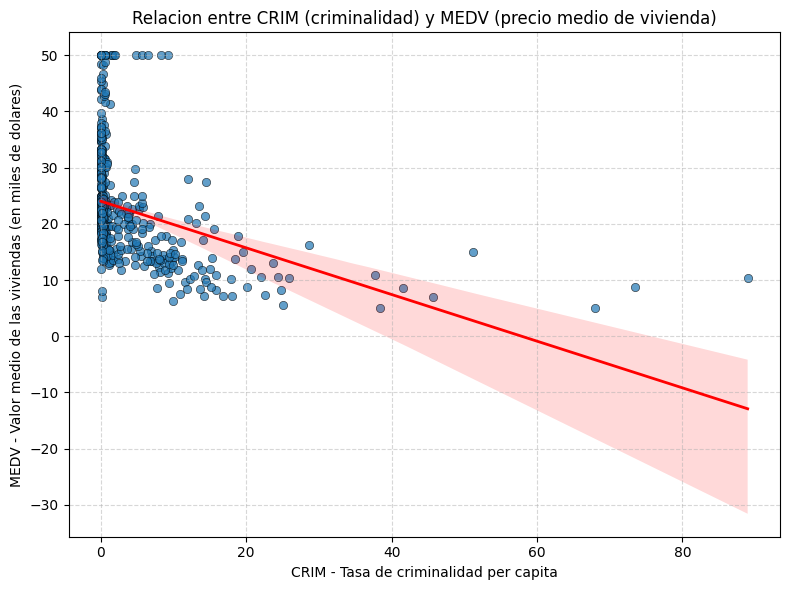

- Al evaluar distintas profundidades (max_depth), se observo que el arbol con profundidad moderada ofrecio el mejor equilibrio entre sesgo y varianza.
- Cuando el arbol crece demasiado (max_depth=None), el rendimiento en entrenamiento es excelente, pero sobreajusta, reduciendo la capacidad de generalizacion en prueba
- El coeficiente R2 en test muestra que el arbol explica una fraccion significativa de la variabilidad en los precios, aunque no toda
- el analisis de residuos indica que los errores se distribuyen de forma centrada, sin sesgo fuerte, aunque existen algunos outliers asociados a viviendas muy caras o muy baratas.

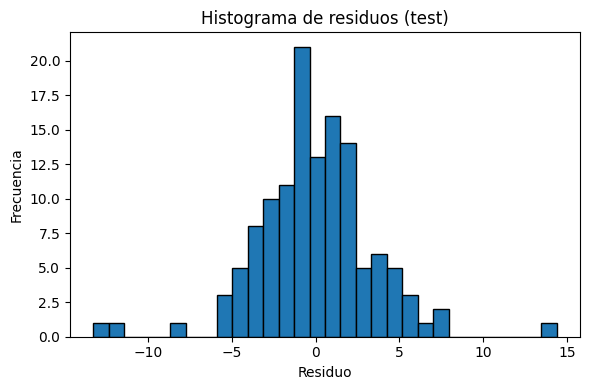